This project explores the effect of removing a key member from a covert social network, using the Cocaine Dealing (Natarajan) dataset as a case study.
The goal was to determine who the most central individual in the network is—someone whose removal would most disrupt communication and coordination within the group.
Using basic network analysis tools in Python’s NetworkX, we examined centrality measures (degree and betweenness) to identify influential actors, then simulated an “intervention” by removing the top broker and observing changes in the network’s structure.

Upload ZIP from file explorer

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Cocaine Dealing Natarajan CSV.zip to Cocaine Dealing Natarajan CSV.zip


Unzip contents of Cocaine Dealing Natarajan CSV.zip

In [2]:
import zipfile, os

zip_path = "Cocaine Dealing Natarajan CSV.zip"
extract_dir = "cocaine_data"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

# list the files that were inside the zip
os.listdir(extract_dir)


['CSV']

See what is inside "CSV" folder

In [3]:
import os

# list everything inside 'CSV' folder
os.listdir("cocaine_data/CSV")


['COCAINE_DEALING.csv']

Load COCAINE_DEALING.csv

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

file_path = "cocaine_data/CSV/COCAINE_DEALING.csv"

adj = pd.read_csv(file_path, index_col=0)
adj.head()


,Bill,Blacky,Bruce,Charles,Dante,David,Donald,Doug,Fabio,Frank,...,Marzio,Menna,Peretta,Peter,Robert,Rosa,Ross,Shawn,Steve,Tommy
Bill,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Blacky,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
Bruce,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Charles,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dante,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


Check if there are zero-weight edges (added after following step below)

In [6]:
zero_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 0) == 0]
print(f"Found {len(zero_edges)} edges with weight 0.")
if len(zero_edges) > 0:
    print("Example few:", zero_edges[:5])


Found 0 edges with weight 0.


Build a directed, weighted graph. Uses directional arrow and strength or frequency of edge.

In [5]:
import networkx as nx
import numpy as np

# 1.1 create a directed graph from the adjacency matrix (adj)
G = nx.from_pandas_adjacency(adj, create_using=nx.DiGraph)

# 1.2 ensure weights are numeric
for u, v, d in G.edges(data=True): #u=source, v=target, d=dictionary {}
    d["weight"] = float(d.get("weight", 0.0))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Nodes: 28
Edges: 40


Sanity checks.  In the Natarajan dataset the weight refers to how frequently the two individuals conducted transactions.  Higher weights indicate stronger connections.  

In [7]:
# nodes present?
list(G.nodes())[:10]

# view top
list(G.edges(data=True))[:10]


[('Blacky', 'Dante', {'weight': 1.0}),
 ('Blacky', 'Frank', {'weight': 1.0}),
 ('Blacky', 'Ross', {'weight': 1.0}),
 ('Dante', 'Robert', {'weight': 1.0}),
 ('Kay', 'Bill', {'weight': 2.0}),
 ('Kay', 'Blacky', {'weight': 10.0}),
 ('Kay', 'Bruce', {'weight': 1.0}),
 ('Kay', 'Charles', {'weight': 3.0}),
 ('Kay', 'Dante', {'weight': 18.0}),
 ('Kay', 'David', {'weight': 6.0})]

For this assignment, we will turn it into an undirected graph to make code easier.  We do not need to know directionality.  We are looking for degree of centrality and betweenness for analysis.

Degree centrality measures how many direct connections a node has.
Nodes with higher degree centrality interact with more individuals.

Betweenness centrality measures how often a node sits on the shortest paths
between other nodes. Nodes with high betweenness act as brokers or gatekeepers
who control information or resource flow in the network.

In [8]:
# turn the directed/weighted graph into a simple undirected graph
Gu = G.to_undirected()

print("Nodes:", Gu.number_of_nodes())
print("Edges:", Gu.number_of_edges())


Nodes: 28
Edges: 40


Calculate degree centrality and betweenness centrality and view top 5.

In [9]:
# degree centrality: "how many neighbors do you have?" (normalized)
deg_c = nx.degree_centrality(Gu)

# betweenness centrality: "how often are you on the shortest paths?"
bet_c = nx.betweenness_centrality(Gu, normalized=True)

# view top 5 w/ lambda
def top5(d):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 by degree:", top5(deg_c))
print("Top 5 by betweenness:", top5(bet_c))


Top 5 by degree: [('Kay', 0.8888888888888888), ('Tommy', 0.25925925925925924), ('Blacky', 0.18518518518518517), ('Menna', 0.18518518518518517), ('Steve', 0.14814814814814814)]
Top 5 by betweenness: [('Kay', 0.8874643874643875), ('Tommy', 0.08831908831908833), ('Steve', 0.0754985754985755), ('Dante', 0.07407407407407408), ('Blacky', 0.011396011396011397)]


Identify top target by degree and betweenness centrality.  In this case this is easily identified as Kay.  

In [10]:
target = max(bet_c, key=bet_c.get)
target


'Kay'

Compare the numbers before and after removing Kay.  Before removal there was only one component (all 28 nodes were connected). After removal there were 12 separate groups.  The largest group had 16 nodes, instead of original 28.

In [11]:
# before removal
num_comp_before = nx.number_connected_components(Gu)
largest_before   = len(max(nx.connected_components(Gu), key=len))

# remove target
Gu_removed = Gu.copy()
Gu_removed.remove_node(target)

# after removal
num_comp_after = nx.number_connected_components(Gu_removed)
largest_after  = len(max(nx.connected_components(Gu_removed), key=len))

print("Removed:", target)
print("Components  (before -> after):", num_comp_before, "->", num_comp_after)
print("Largest comp (before -> after):", largest_before,  "->", largest_after)


Removed: Kay
Components  (before -> after): 1 -> 12
Largest comp (before -> after): 28 -> 16


This is an ugly graph.  I will try using Gephi Lite next.  

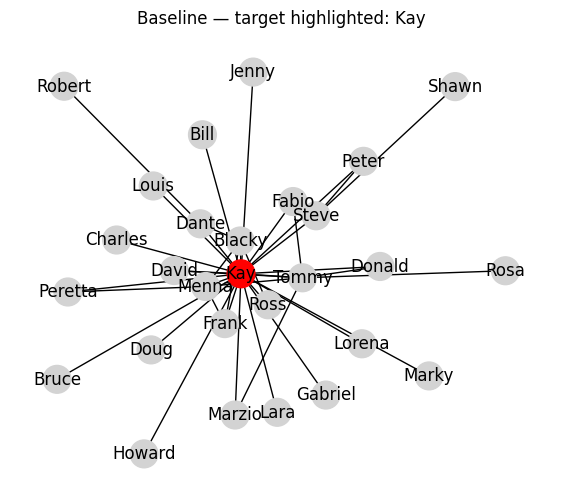

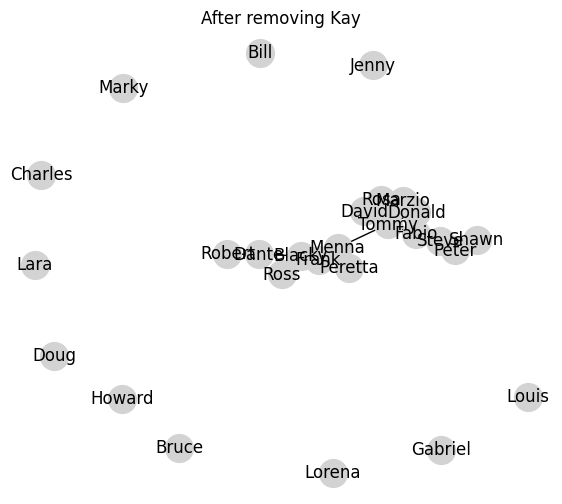

In [12]:
import matplotlib.pyplot as plt

# baseline layout (fixed seed so it doesn't jump around)
pos = nx.spring_layout(Gu, seed=42)

# before: highlight the target in red
plt.figure(figsize=(7,6))
node_colors = ["red" if n == target else "lightgray" for n in Gu.nodes()]
nx.draw_networkx(Gu, pos, with_labels=True, node_color=node_colors, node_size=400)
plt.title(f"Baseline — target highlighted: {target}")
plt.axis("off")
plt.show()

# after: draw the graph with the node removed
pos2 = nx.spring_layout(Gu_removed, seed=42)
plt.figure(figsize=(7,6))
nx.draw_networkx(Gu_removed, pos2, with_labels=True, node_color="lightgray", node_size=400)
plt.title(f"After removing {target}")
plt.axis("off")
plt.show()


I want to export my edge list and node attributes to my computer, then upload into Gephi.  

In [13]:
# Attach centrality values to each node as attributes
for n in Gu.nodes():
    Gu.nodes[n]["degree"] = deg_c.get(n, 0)
    Gu.nodes[n]["betweenness"] = bet_c.get(n, 0)

# Write graph (with attributes) to GEXF for Gephi / Gephi Lite
nx.write_gexf(Gu, "cocaine_network_with_attrs.gexf")

# Download the GEXF file from Colab
from google.colab import files
files.download("cocaine_network_with_attrs.gexf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Issues with saving from Gephi Lite, screenshot saved.  Now uploading.  

In [14]:
from google.colab import files
uploaded = files.upload()  # pick your file, e.g., cocaine_network_final.png


![Figure 1. Visualization of the *Cocaine Dealing (Natarajan)* network — nodes sized by degree centrality and colored by betweenness centrality. Kay appears as the central broker; her removal fragments the network into smaller clusters.](cocaine-network-gephi.png)


The Cocaine Dealing (Natarajan) network consisted of 28 individuals connected by 40 relationships, represented as an undirected, unweighted graph.
Two centrality measures were calculated to identify the most influential member:

Degree centrality, which reflects how many direct connections each person has.

Betweenness centrality, which reflects how often a person lies on the shortest communication paths between others and thus can control or broker information flow.

Both measures identified Kay as the most central individual, with exceptionally high degree (0.89) and betweenness (0.89) values.
This suggested that Kay served as a critical connector between otherwise separate subgroups within the network.

To test this, Kay was “removed” from the graph, and basic metrics were compared before and after.
Following removal, the number of connected components increased sharply from 1 to 12, and the largest connected group shrank from 28 to 16 members.
This fragmentation indicates that the network relies heavily on Kay to maintain overall structure and communication.
Her removal effectively breaks the organization into smaller, disconnected clusters.

In summary, while this analysis does not reveal who supplied or produced the cocaine, the structural pattern strongly suggests Kay was the central broker or coordinator in this network.  Kay represents the key bridging node or “weakest link” in the network—the individual whose absence most disrupts connectivity and cohesion.
This simple experiment demonstrates how social network analysis can identify critical actors in covert or criminal groups, even with basic graph-based methods.